# IMPORTS

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.times.times import TimestampSanitizer

# LOAD DATA

## MDS versions

In [2]:
SOURCEDIR = r"../../50_REDDYPROC"
FILENAME = r"51.1_UstarThresholds_MDS-gapfilled_NEE-partitioned.csv"
FILEPATH = Path(SOURCEDIR) / FILENAME
mds = pd.read_csv(FILEPATH)

# Convert timestamp to datetime and change from end to middle
mds['TIMESTAMP_MIDDLE'] = pd.to_datetime(mds['TIMESTAMP_END'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce') - pd.Timedelta(minutes=15)
# Drop the timestamp end
mds.drop(columns='TIMESTAMP_END', inplace=True)
# Set the timestamp as index
mds.set_index('TIMESTAMP_MIDDLE', inplace=True)

# Rename for consistent naming with XGBoost versions
renaming_dict = {
    'NEE_U16_f': 'NEE_L3.3_CUT_16_QCF_footprint_gfMDS',
    'NEE_U50_f': 'NEE_L3.3_CUT_50_QCF_footprint_gfMDS',
    'NEE_U84_f': 'NEE_L3.3_CUT_84_QCF_footprint_gfMDS',
    'Reco_U16': 'RECO_NT_CUT_16_QCF_footprint_gfMDS',
    'Reco_U50': 'RECO_NT_CUT_50_QCF_footprint_gfMDS',
    'Reco_U84': 'RECO_NT_CUT_84_QCF_footprint_gfMDS',
    'GPP_U16_f': 'GPP_NT_CUT_16_QCF_footprint_gfMDS',
    'GPP_U50_f': 'GPP_NT_CUT_50_QCF_footprint_gfMDS',
    'GPP_U84_f': 'GPP_NT_CUT_84_QCF_footprint_gfMDS',
    'LE_f': 'LE_L3.2_QCF_footprint_gfMDS',
    'H_f': 'H_L3.2_QCF_footprint_gfMDS'
}
mds.rename(columns=renaming_dict, inplace=True)

# Drop thresholds
mds = mds[[c for c in renaming_dict.values()]].copy()

mds

,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-10-18 10:45:00,1.328996,1.406032,1.406032,2.042440,1.976069,2.040065,0.713445,0.570038,0.634034,28.859389,-9.798868
2023-10-18 11:15:00,0.976800,1.066060,1.066060,2.060760,1.993574,2.057418,1.083960,0.927514,0.991358,32.974414,1.894386
2023-10-18 11:45:00,0.976800,1.066060,1.066060,2.102240,2.033204,2.096681,1.125441,0.967144,1.030621,32.974414,4.722599
2023-10-18 12:15:00,0.732042,0.732042,0.732042,2.125441,2.055365,2.118624,1.393399,1.323323,1.386582,35.773866,11.019241
2023-10-18 12:45:00,0.941541,0.941541,0.941541,2.224081,2.149553,2.211782,1.282540,1.208011,1.270240,37.060974,3.519276
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,10.578562,10.578562,8.484814,9.021079,9.063208,-2.093748,-1.557483,-1.515354,2.365148,-37.795644
2025-06-04 22:15:00,9.416519,9.416519,9.416519,8.410086,8.942601,8.987474,-1.006432,-0.473917,-0.429044,3.145603,-33.579604
2025-06-04 22:45:00,10.095010,10.095010,10.095010,8.470697,9.006254,9.048903,-1.624313,-1.088756,-1.046107,3.778325,-38.997547


## XGBoost versions

### Gap-filling results

In [3]:
gapfilled_df = load_parquet(Path("81.4.1_NEE_GF-XGBoost.parquet"))
gapfilled_df

Loaded .parquet file 81.4.1_NEE_GF-XGBoost.parquet (0.334 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF0_parcelA,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaEns,...,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_yhat,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost,FLAG_NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_ISFILLED,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_sigmaGF,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_sigmaResid,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_sigmaEns,NEE_L3.3_CUT_84_QCF_footprint_gfXGBoost_total_unc,NEE_L3.3_CUT_84_QCF0_footprint,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_yhat,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost,FLAG_NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ISFILLED,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_sigmaGF,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_sigmaResid,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_sigmaEns,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_total_unc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-18 00:15:00,NaN,1.337490,1.337490,1,0.447234,0.707455,0.836965,0.836965,NaN,1.337490,1.337490,1,0.447234,0.707455,0.836965,...,1.510508,1.510508,1,0.748387,0.676079,1.008547,1.008547,NaN,1.510508,1.510508,1,0.748387,0.676079,1.008547,1.008547
2023-10-18 00:45:00,NaN,1.198726,1.198726,1,0.389184,0.707455,0.807438,0.807438,NaN,1.198726,1.198726,1,0.389184,0.707455,0.807438,...,1.455824,1.455824,1,0.800935,0.676079,1.048132,1.048132,NaN,1.455824,1.455824,1,0.800935,0.676079,1.048132,1.048132
2023-10-18 01:15:00,NaN,1.410799,1.410799,1,0.361651,0.707455,0.794533,0.794533,NaN,1.410799,1.410799,1,0.361651,0.707455,0.794533,...,1.792818,1.792818,1,0.728272,0.676079,0.993712,0.993712,NaN,1.792818,1.792818,1,0.728272,0.676079,0.993712,0.993712
2023-10-18 01:45:00,NaN,1.701339,1.701339,1,0.390163,0.707455,0.807911,0.807911,NaN,1.701339,1.701339,1,0.390163,0.707455,0.807911,...,1.936059,1.936059,1,0.620086,0.676079,0.917382,0.917382,NaN,1.936059,1.936059,1,0.620086,0.676079,0.917382,0.917382
2023-10-18 02:15:00,NaN,1.776067,1.776067,1,0.343278,0.707455,0.786341,0.786341,NaN,1.776067,1.776067,1,0.343278,0.707455,0.786341,...,1.952504,1.952504,1,0.706808,0.676079,0.978090,0.978090,NaN,1.952504,1.952504,1,0.706808,0.676079,0.978090,0.978090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,7.482226,7.482226,1,0.535898,2.020721,2.090574,2.090574,NaN,7.482226,7.482226,1,0.535898,2.020721,2.090574,...,8.004314,8.004314,1,0.884405,1.960723,2.150955,2.150955,NaN,8.004314,8.004314,1,0.884405,1.960723,2.150955,2.150955
2025-06-05 22:15:00,NaN,8.001804,8.001804,1,0.480655,2.020721,2.077100,2.077100,NaN,8.001804,8.001804,1,0.480655,2.020721,2.077100,...,8.102103,8.102103,1,0.727730,1.960723,2.091417,2.091417,NaN,8.102103,8.102103,1,0.727730,1.960723,2.091417,2.091417
2025-06-05 22:45:00,NaN,8.192554,8.192554,1,0.409161,2.020721,2.061729,2.061729,NaN,8.192554,8.192554,1,0.409161,2.020721,2.061729,...,8.520823,8.520823,1,0.626255,1.960723,2.058307,2.058307,NaN,8.520823,8.520823,1,0.626255,1.960723,2.058307,2.058307


### Partitioning results

In [4]:
part_path = "81.5.1_NEE_XG-GAPF_PART_ReddyProc.csv"
part_df = pd.read_csv(part_path)
part_df = part_df.set_index("TIMESTAMP")
part_df.index.name = "TIMESTAMP_END"
part_df = TimestampSanitizer(data=part_df).get()
part_df

,Tair_orig,Tair_f,Tair_fqc,Tair_fall,Tair_fall_qc,Tair_fnum,Tair_fsd,Tair_fmeth,Tair_fwin,Rg_orig,Rg_f,Rg_fqc,Rg_fall,Rg_fall_qc,Rg_fnum,...,FP_GPP2000,FP_k,FP_beta,FP_alpha,FP_RRef,FP_E0,FP_k_sd,FP_beta_sd,FP_alpha_sd,FP_RRef_sd,FP_E0_sd,Reco_DT_QCF0,GPP_DT_QCF0,Reco_DT_QCF0_SD,GPP_DT_QCF0_SD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 22:15:00,7.466667,7.466667,0,7.466667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.690468,0.000000,0.196265,0.00000
2023-10-17 22:45:00,7.300000,7.300000,0,7.300000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649720,0.000000,0.197728,0.00000
2023-10-17 23:15:00,7.233333,7.233333,0,7.233333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.633524,0.000000,0.198295,0.00000
2023-10-17 23:45:00,7.100000,7.100000,0,7.100000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.601307,0.000000,0.199399,0.00000
2023-10-18 00:15:00,6.900000,6.900000,0,6.900000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.553423,0.000000,0.200977,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 19:45:00,16.290000,16.290000,0,16.290000,NaN,NaN,NaN,NaN,NaN,26.336951,26.336951,0,26.336951,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.238497,3.808866,0.353677,0.20307
2025-06-04 20:15:00,16.073333,16.073333,0,16.073333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.143821,0.000000,0.345543,0.00000
2025-06-04 20:45:00,15.886667,15.886667,0,15.886667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.062432,0.000000,0.339350,0.00000


# CLEAN PARTITIONING RESULTS

## Identify GPP and RECO columns

In [5]:
partcols = [c for c in part_df.columns if any(substring in c for substring in ["GPP", "Reco"])];
partcols = [c for c in partcols if not str(c).endswith("_fqc") and not str(c).endswith("_SD") and '_DT' not in c] 
partcols.remove("FP_GPP2000")
partcols

['Reco_QCF', 'GPP_QCF_f', 'Reco_QCF0', 'GPP_QCF0_f']

## Create subset with GPP and RECO columns

In [6]:
subset_partcols = part_df[partcols].copy()
subset_partcols

,Reco_QCF,GPP_QCF_f,Reco_QCF0,GPP_QCF0_f
TIMESTAMP_MIDDLE,,,,
2023-10-17 22:15:00,2.817731,0.413337,2.817731,0.413337
2023-10-17 22:45:00,2.805650,0.389104,2.805650,0.389104
2023-10-17 23:15:00,2.800812,0.384858,2.800812,0.384858
2023-10-17 23:45:00,2.791123,0.401707,2.791123,0.401707
2023-10-18 00:15:00,2.776561,1.284265,2.776561,1.284265
...,...,...,...,...
2025-06-04 19:45:00,8.868652,1.726356,8.868652,1.726356
2025-06-04 20:15:00,8.832214,-0.875965,8.832214,-0.875965
2025-06-04 20:45:00,8.800737,-1.367380,8.800737,-1.367380


## Rename partitioning variables

In [7]:
renaming_dict = {
    # Nighttime paritioning results for parcels A and B
    'GPP_QCF_f': 'GPP_NT_CUT_50_QCF_footprint_gfXGBoost', 
    'GPP_QCF0_f': 'GPP_NT_CUT_50_QCF0_footprint_gfXGBoost',
    'Reco_QCF': 'RECO_NT_CUT_50_QCF_footprint_gfXGBoost',
    'Reco_QCF0': 'RECO_NT_CUT_50_QCF0_footprint_gfXGBoost'
}

subset_partcols = subset_partcols.rename(columns=renaming_dict, inplace=False)
subset_partcols

,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost
TIMESTAMP_MIDDLE,,,,
2023-10-17 22:15:00,2.817731,0.413337,2.817731,0.413337
2023-10-17 22:45:00,2.805650,0.389104,2.805650,0.389104
2023-10-17 23:15:00,2.800812,0.384858,2.800812,0.384858
2023-10-17 23:45:00,2.791123,0.401707,2.791123,0.401707
2023-10-18 00:15:00,2.776561,1.284265,2.776561,1.284265
...,...,...,...,...
2025-06-04 19:45:00,8.868652,1.726356,8.868652,1.726356
2025-06-04 20:15:00,8.832214,-0.875965,8.832214,-0.875965
2025-06-04 20:45:00,8.800737,-1.367380,8.800737,-1.367380


# MERGE

In [8]:
df = pd.concat([gapfilled_df, subset_partcols, mds], axis=1)
df

,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF0_parcelA,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF0_parcelA_gfXGBoost_sigmaEns,...,RECO_NT_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,RECO_NT_CUT_50_QCF0_footprint_gfXGBoost,GPP_NT_CUT_50_QCF0_footprint_gfXGBoost,NEE_L3.3_CUT_16_QCF_footprint_gfMDS,NEE_L3.3_CUT_50_QCF_footprint_gfMDS,NEE_L3.3_CUT_84_QCF_footprint_gfMDS,RECO_NT_CUT_16_QCF_footprint_gfMDS,RECO_NT_CUT_50_QCF_footprint_gfMDS,RECO_NT_CUT_84_QCF_footprint_gfMDS,GPP_NT_CUT_16_QCF_footprint_gfMDS,GPP_NT_CUT_50_QCF_footprint_gfMDS,GPP_NT_CUT_84_QCF_footprint_gfMDS,LE_L3.2_QCF_footprint_gfMDS,H_L3.2_QCF_footprint_gfMDS
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.817731,0.413337,2.817731,0.413337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.805650,0.389104,2.805650,0.389104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.800812,0.384858,2.800812,0.384858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.791123,0.401707,2.791123,0.401707,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-18 00:15:00,NaN,1.337490,1.337490,1.0,0.447234,0.707455,0.836965,0.836965,NaN,1.337490,1.337490,1.0,0.447234,0.707455,0.836965,...,2.776561,1.284265,2.776561,1.284265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,7.482226,7.482226,1.0,0.535898,2.020721,2.090574,2.090574,NaN,7.482226,7.482226,1.0,0.535898,2.020721,2.090574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,8.001804,8.001804,1.0,0.480655,2.020721,2.077100,2.077100,NaN,8.001804,8.001804,1.0,0.480655,2.020721,2.077100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,8.192554,8.192554,1.0,0.409161,2.020721,2.061729,2.061729,NaN,8.192554,8.192554,1.0,0.409161,2.020721,2.061729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# PLOT

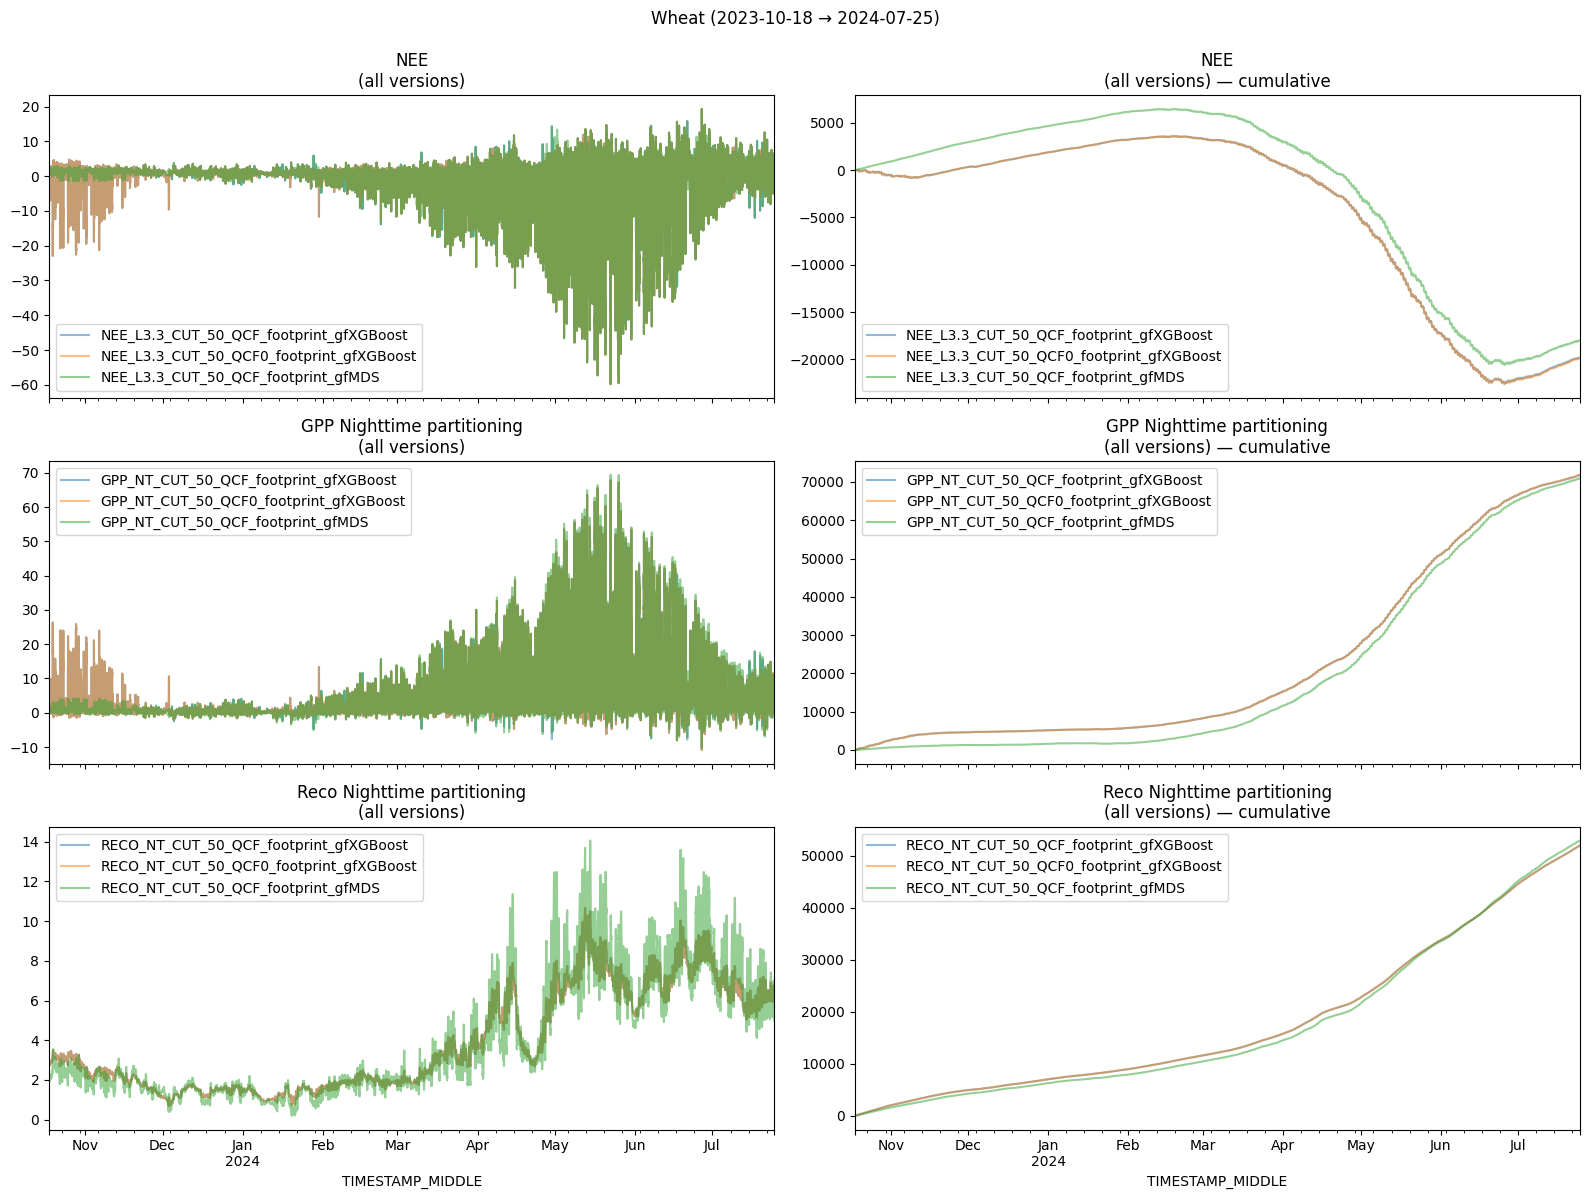

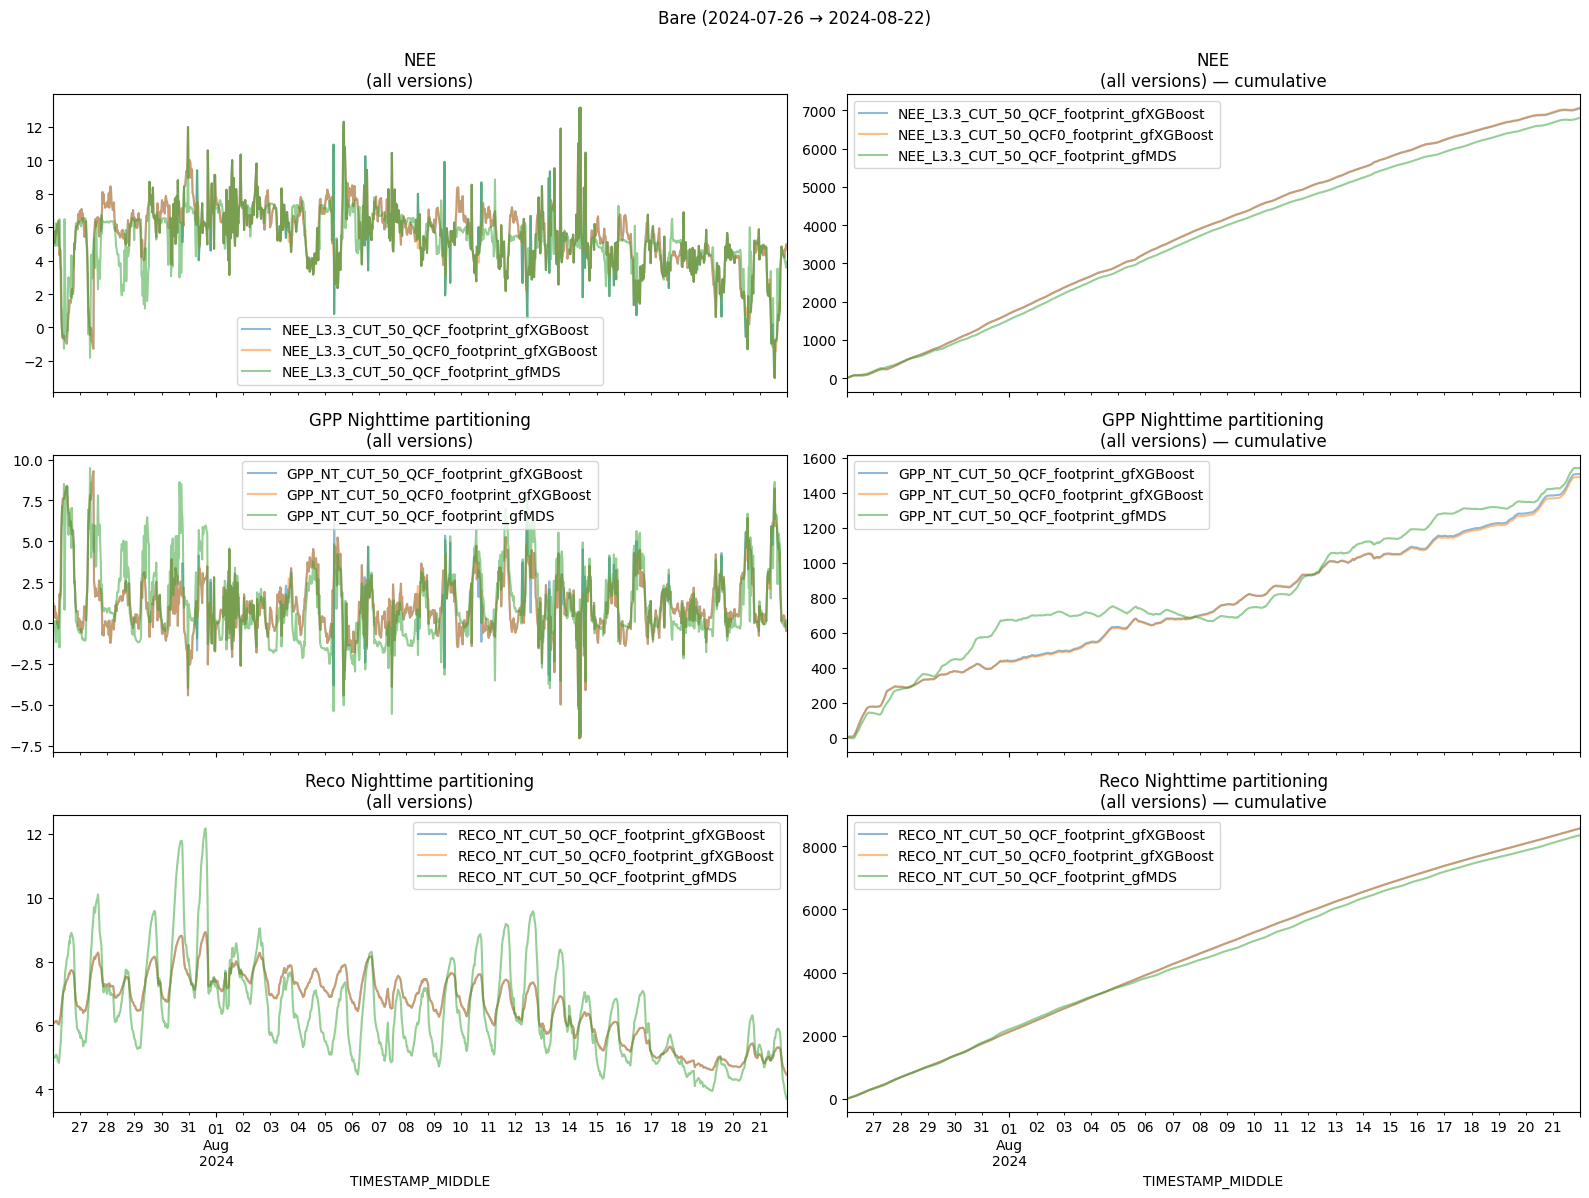

In [9]:
# Define periods
periods = [
    ("2023-10-18", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-08-22", "Bare"),
]

for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    pairs = [
        ([c for c in df.columns if c.startswith('NEE_L3.3_CUT_50') and (c.endswith('footprint_gfXGBoost') or c.endswith('footprint_gfMDS'))], "NEE\n(all versions)"),       
        ([c for c in df.columns if c.startswith('GPP_NT_CUT_50')], "GPP Nighttime partitioning\n(all versions)"),
        ([c for c in df.columns if c.startswith('RECO_NT_CUT_50')], "Reco Nighttime partitioning\n(all versions)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.5)
        axes[r, 0].set_title(f"{t}")

        # cumulative
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.5)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT DATA

In [10]:
filename = "81.6.1_NEE_GF-XGBoost_GPP_RECO"
save_parquet(data=df, filename=filename)

Saved file 81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet (1.334 seconds).


'81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet'

# End of notebook

In [11]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-02-24 14:11:20
